In [8]:
"""Entity-Embedding Tabular MLP demo notebook."""

import math
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Ensure src is on path for shared constants and helpers
ROOT = Path.cwd().parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from data.constants import CAT_COLS, NUMERIC_COLS, LOG_COLS, TARGET_COL, MIN_FREQ
import data.encode_features as enc

In [9]:
class EntityEmbeddingMLP(nn.Module):
    """Entity-Embedding MLP for mixed categorical + numeric features."""

    def __init__(
        self,
        cat_cardinalities: dict[str, int],
        num_features: int,
        emb_dims: dict[str, int] | None = None,
        hidden_sizes: list[int] | None = None,
        dropout: float = 0.0,
        use_batchnorm: bool = False,
        out_dim: int = 1,
    ) -> None:
        super().__init__()
        hidden_sizes = hidden_sizes or []
        self.cat_cardinalities = dict(cat_cardinalities)
        self.cat_names = list(cat_cardinalities.keys())  # deterministic order
        self.num_features = int(num_features)
        self.emb_dims = emb_dims or {}
        self.use_batchnorm = use_batchnorm
        self.dropout = dropout
        self.out_dim = out_dim

        # Build embeddings
        embs = {}
        for name, card in self.cat_cardinalities.items():
            dim = self.emb_dims.get(name)
            if dim is None:
                dim = int(round(math.sqrt(card) + 1))
                dim = min(50, max(1, dim))
            if card <= 0:
                raise ValueError(f"Cardinality for {name} must be > 0 (got {card})")
            embs[name] = nn.Embedding(card, dim)
        self.embeddings = nn.ModuleDict(embs)

        total_emb = sum(self.embeddings[name].embedding_dim for name in self.cat_names)
        self.total_embedding_dim = total_emb
        self.input_dim = total_emb + self.num_features

        layers: list[nn.Module] = []
        in_dim = self.input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            if self.use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if self.dropout > 0:
                layers.append(nn.Dropout(self.dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, out_dim))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x_cat: dict[str, torch.Tensor], x_num: torch.Tensor) -> torch.Tensor:
        # Type and shape checks
        if not isinstance(x_cat, dict):
            raise TypeError("x_cat must be a dict[str, Tensor]")
        if x_num.dtype not in (torch.float32, torch.float64, torch.float16, torch.bfloat16):
            raise TypeError(f"x_num must be float tensor, got {x_num.dtype}")
        batch_size = x_num.shape[0]
        embeds = []
        for name in self.cat_names:
            if name not in x_cat:
                raise KeyError(f"Missing categorical feature: {name}")
            t = x_cat[name]
            if t.dtype != torch.int64:
                raise TypeError(f"x_cat[{name}] must be int64, got {t.dtype}")
            if t.ndim != 1:
                raise ValueError(f"x_cat[{name}] must be 1D [B], got shape {tuple(t.shape)}")
            if t.shape[0] != batch_size:
                raise ValueError(
                    f"Batch mismatch for {name}: expected {batch_size}, got {t.shape[0]}"
                )
            embeds.append(self.embeddings[name](t))
        num = x_num
        if num.ndim != 2 or num.shape[1] != self.num_features:
            raise ValueError(
                f"x_num must be [B, {self.num_features}], got {tuple(num.shape)}"
            )
        x = torch.cat(embeds + [num], dim=1)
        return self.mlp(x)

    @property
    def embedding_dims(self) -> dict[str, int]:
        return {k: self.embeddings[k].embedding_dim for k in self.cat_names}


In [10]:
# Sanity check: dummy data forward pass
cat_cardinalities_demo = {c: 10 for c in CAT_COLS[:3]}  # small subset
model_demo = EntityEmbeddingMLP(
    cat_cardinalities=cat_cardinalities_demo,
    num_features=4,
    hidden_sizes=[16, 8],
    dropout=0.1,
    use_batchnorm=True,
    out_dim=1,
)

batch_size = 5
x_cat_demo = {c: torch.randint(0, card, (batch_size,), dtype=torch.int64) for c, card in cat_cardinalities_demo.items()}
x_num_demo = torch.randn(batch_size, 4)

out_demo = model_demo(x_cat_demo, x_num_demo)
print("Demo output shape:", out_demo.shape)
print("Total embedding dim:", model_demo.total_embedding_dim)
print("Input dim:", model_demo.input_dim)


Demo output shape: torch.Size([5, 1])
Total embedding dim: 12
Input dim: 16


In [11]:
# Build tensors using src/data/encode_features helpers + prepare_features

data_dir = ROOT / "data" / "processed" / "all_features"
train_df = pd.read_csv(data_dir / "train.csv")
val_df = pd.read_csv(data_dir / "val.csv")
test_df = pd.read_csv(data_dir / "test.csv")

# Use the shared preprocessing to get scaled numerics, artifacts, and y
X_train_np, X_val_np, X_test_np, y_train_np, y_val_np, y_test_np, artifacts = enc.prepare_features(
    train_df, val_df, test_df
)
cat_maps = artifacts["category_maps"]


def cat_tensors_from_maps(df: pd.DataFrame, cat_maps: dict[str, set]):
    df_cat = enc.fill_unknown_categories(df, CAT_COLS)
    df_cat = enc.apply_rare_grouping(df_cat, cat_maps)
    cat_idx: dict[str, torch.Tensor] = {}
    cat_card: dict[str, int] = {}
    for col in CAT_COLS:
        vocab = ["Unknown", "Other"] + sorted(cat_maps[col])
        seen = set()
        vocab_unique = []
        for v in vocab:
            if v not in seen:
                vocab_unique.append(v)
                seen.add(v)
        mapping = {v: i for i, v in enumerate(vocab_unique)}
        cat_idx[col] = torch.tensor(
            df_cat[col].map(mapping).fillna(mapping["Unknown"]).astype(np.int64).values
        )
        cat_card[col] = len(mapping)
    return cat_idx, cat_card

train_cat_idx, cat_cardinalities = cat_tensors_from_maps(train_df, cat_maps)
val_cat_idx, _ = cat_tensors_from_maps(val_df, cat_maps)
test_cat_idx, _ = cat_tensors_from_maps(test_df, cat_maps)

# Numeric tensors from prepare_features (first NUMERIC_COLS entries are scaled numerics)
train_num = torch.tensor(X_train_np[:, : len(NUMERIC_COLS)], dtype=torch.float32)
val_num = torch.tensor(X_val_np[:, : len(NUMERIC_COLS)], dtype=torch.float32)
test_num = torch.tensor(X_test_np[:, : len(NUMERIC_COLS)], dtype=torch.float32)
train_y = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1)
val_y = torch.tensor(y_val_np, dtype=torch.float32).unsqueeze(1)
test_y = torch.tensor(y_test_np, dtype=torch.float32).unsqueeze(1)

# Instantiate model with real cardinalities
model_real = EntityEmbeddingMLP(
    cat_cardinalities=cat_cardinalities,
    num_features=len(NUMERIC_COLS),
    hidden_sizes=[256, 128, 64],
    dropout=0.1,
    use_batchnorm=True,
    out_dim=1,
)

# Forward pass on a small batch
batch = 32
subset = slice(0, min(batch, train_num.shape[0]))
out_real = model_real({k: v[subset] for k, v in train_cat_idx.items()}, train_num[subset])
print("Real-data forward output shape:", out_real.shape)


Real-data forward output shape: torch.Size([32, 1])


In [12]:
# Training loop demo on processed data

epochs = 200
batch_size = 256
lr = 1e-3

def batch_iterator(cat_idx: dict[str, torch.Tensor], num: torch.Tensor, y: torch.Tensor, shuffle: bool = True):
    n = num.shape[0]
    order = torch.randperm(n) if shuffle else torch.arange(n)
    for start in range(0, n, batch_size):
        idx = order[start : start + batch_size]
        yield {k: v[idx] for k, v in cat_idx.items()}, num[idx], y[idx]

model_train = EntityEmbeddingMLP(
    cat_cardinalities=cat_cardinalities,
    num_features=len(NUMERIC_COLS),
    hidden_sizes=[256, 128, 64],
    dropout=0.1,
    use_batchnorm=True,
    out_dim=1,
)
optimizer = torch.optim.Adam(model_train.parameters(), lr=lr)
loss_fn = nn.MSELoss()

train_losses = []
val_losses = []

for epoch in range(1, epochs + 1):
    model_train.train()
    train_loss = 0.0
    steps = 0
    for cat_b, num_b, y_b in batch_iterator(train_cat_idx, train_num, train_y, shuffle=True):
        optimizer.zero_grad()
        pred = model_train(cat_b, num_b).squeeze(-1)
        loss = loss_fn(pred, y_b.squeeze(-1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        steps += 1
    train_loss /= max(steps, 1)

    model_train.eval()
    val_loss = 0.0
    val_steps = 0
    with torch.no_grad():
        for cat_b, num_b, y_b in batch_iterator(val_cat_idx, val_num, val_y, shuffle=False):
            pred = model_train(cat_b, num_b).squeeze(-1)
            loss = loss_fn(pred, y_b.squeeze(-1))
            val_loss += loss.item()
            val_steps += 1
    val_loss /= max(val_steps, 1)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}: train_loss={train_loss:.4f} val_loss={val_loss:.4f}")


Epoch 01: train_loss=292.6753 val_loss=294.5423
Epoch 10: train_loss=138.0636 val_loss=128.4904
Epoch 20: train_loss=23.0310 val_loss=23.5331
Epoch 30: train_loss=3.3400 val_loss=3.0625
Epoch 40: train_loss=2.2604 val_loss=1.6656
Epoch 50: train_loss=2.2347 val_loss=1.3590
Epoch 60: train_loss=2.1117 val_loss=1.3151
Epoch 70: train_loss=2.0299 val_loss=1.3398
Epoch 80: train_loss=1.9783 val_loss=1.2517
Epoch 90: train_loss=1.9170 val_loss=1.1946
Epoch 100: train_loss=1.8495 val_loss=1.2182
Epoch 110: train_loss=1.7382 val_loss=1.3949
Epoch 120: train_loss=1.6486 val_loss=1.3371
Epoch 130: train_loss=1.6651 val_loss=1.1998
Epoch 140: train_loss=1.5642 val_loss=1.3828
Epoch 150: train_loss=1.5979 val_loss=1.3481
Epoch 160: train_loss=1.5348 val_loss=1.3963
Epoch 170: train_loss=1.5659 val_loss=1.2225
Epoch 180: train_loss=1.5529 val_loss=1.3285
Epoch 190: train_loss=1.5170 val_loss=1.2712
Epoch 200: train_loss=1.5038 val_loss=1.2842


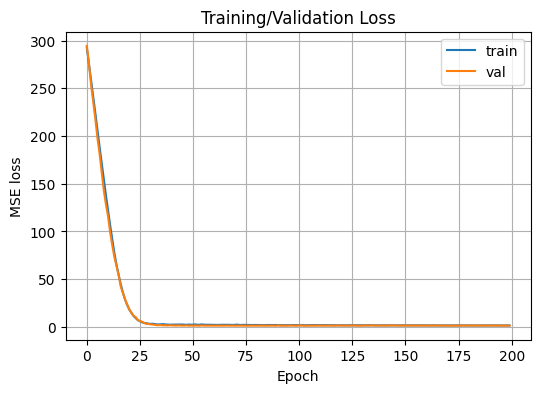

Test loss: 1.1857


In [13]:
# Plot loss curves and evaluate on test set
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training/Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Test evaluation
model_train.eval()
test_loss = 0.0
test_steps = 0
with torch.no_grad():
    for cat_b, num_b, y_b in batch_iterator(test_cat_idx, test_num, test_y, shuffle=False):
        pred = model_train(cat_b, num_b).squeeze(-1)
        loss = loss_fn(pred, y_b.squeeze(-1))
        test_loss += loss.item()
        test_steps += 1
test_loss /= max(test_steps, 1)
print(f"Test loss: {test_loss:.4f}")


In [20]:
# Inspect a few test examples: predictions vs targets
num_examples = 20
indices = torch.arange(min(num_examples, test_num.shape[0]))
with torch.no_grad():
    preds = model_train({k: v[indices] for k, v in test_cat_idx.items()}, test_num[indices]).squeeze(-1)

pred_log = preds.cpu().numpy()
true_log = test_y[indices].squeeze(-1).cpu().numpy()

results_df = pd.DataFrame({
    "name": test_df.iloc[indices]["name"].values,
    "pred_log_gross": pred_log,
    "true_log_gross": true_log,
    "delta_log_gross": np.abs(pred_log - true_log),
    "pred_gross": np.expm1(pred_log),
    "true_gross": np.expm1(true_log),
    "delta_gross": np.abs(np.expm1(pred_log) - np.expm1(true_log)),
})
# Display without scientific notation
with pd.option_context("display.float_format", "{:.2f}".format):
    display(results_df)


,name,pred_log_gross,true_log_gross,delta_log_gross,pred_gross,true_gross,delta_gross
0,Twilight Zone: The Movie,16.81,17.20,0.38,20075140.00,29450940.00,9375800.00
1,No Country for Old Men,18.49,18.96,0.47,107568976.00,171627072.00,64058096.00
2,The Place Beyond the Pines,17.73,17.67,0.06,49989880.00,47052868.00,2937012.00
3,Supercop,15.23,16.60,1.37,4127481.25,16270591.00,12143110.00
4,Zack and Miri Make a Porno,17.98,17.57,0.41,64293164.00,42784308.00,21508856.00
5,The Best of Enemies,15.49,16.14,0.65,5320138.00,10209820.00,4889682.00
6,The Pursuit of D.B. Cooper,14.15,15.12,0.97,1403650.62,3702027.75,2298377.00
7,The Adventures of Tintin,20.27,19.74,0.53,634938816.00,373993856.00,260944960.00
8,The Kiss,13.64,14.44,0.81,835042.12,1869148.88,1034106.75
9,Lethal Weapon 3,18.96,19.59,0.63,171631664.00,321731424.00,150099760.00
